In [ ]:
# TODO:
# final visualization of centroids (hard bc 40 dimensions...)?? 

# clean up code (image saving, etc)?
# re-run final, clean code?

## Setup

IMPORTANT: in case files in /home/ubuntu/Project/libero_development/src/ are changed, must also submit them to workers (to avoid reading from an old file on WORKER'S disk): from head VM's terminal, run:

```bash
SRC_DIR="/home/ubuntu/Project/libero_development/src"
DEST_DIR="/home/ubuntu/Project/libero_development/src"

WORKER_IPS=(
    "10.67.22.254" "10.67.22.34" "10.67.22.145" "10.67.22.121"
    "10.67.22.192" "10.67.22.18" "10.67.22.187" "10.67.22.48"
)

for ip in "${WORKER_IPS[@]}"; do
    echo "Syncing src/ to $ip..."
    ssh -o StrictHostKeyChecking=no ubuntu@"$ip" "mkdir -p $DEST_DIR"
    rsync -avz --exclude '__pycache__/' "$SRC_DIR/" ubuntu@"$ip":"$DEST_DIR/"
done
```


IMPORTANT: to kill existing Dask processes (from bash):
```bash
for ip in 10.67.22.194 10.67.22.254 10.67.22.34 10.67.22.145 10.67.22.121 10.67.22.192 10.67.22.18 10.67.22.187 10.67.22.48; do
    echo "Killing on $ip..."
    ssh -o StrictHostKeyChecking=no ubuntu@"$ip" "pkill -9 -f dask-scheduler; pkill -9 -f dask-worker; pkill -9 -f dask_ssh" 
done
```

USEFUL: per combinare i risultati di vari csv in un unico csv:
```bash
head -n 1 file.csv > combined.csv
for file in *i_tuoi_file*.csv; do tail -n +2 "$file" >> combined.csv; done
```

USEFUL: to check if a certain port occupied prevents strating worker(s):
```bash
ssh ubuntu@10.67.22.194 "lsof -i :8786"
```
then to kill eg this PID:
```bash
ssh ubuntu@10.67.22.194 "fuser -k 8786/tcp"
```


In [8]:
from src.launch_cluster import launch_cluster, shutdown_cluster

In [9]:
import numpy as np
import pandas as pd
from src.kmeans_parallel import kmeans_parallel
from src.data_loader import load_dataset
from src.benchmark import run_single_test, run_benchmark, calculate_inertia, combinations_fn

import time

In [10]:
# --- Cluster ---
N_WORKERS = 8      # tra 1 e 8 (nodi disponibili in launch_cluster.py)
NUM_PARTITIONS = 8 * N_WORKERS   # regola empirica: >= n_threads_per_worker * n_workers
# --- Algoritmo k-means|| ---
#K = 500                # numero di cluster finali
#L = 250                # oversampling factor (assoluto). In alternativa: L = round(L_OVER_K * K)
#R = 10                  # numero di round dell'inizializzazione parallela
#MAX_ITER_FIT = 100      # iterazioni massime della fase di Lloyd's (fit)

SEED = 42

In [11]:
# --- Dataset ---
DATASET_URL_10PC = "https://ndownloader.figshare.com/files/5976042"
# link used by sklearn function fetch_kddcup99 (original link gives 403 error)
#***for 10% dataset***

DATASET_URL_FULL="https://ndownloader.figshare.com/files/5976045"
#***FULL DATASET***

RAW_GZ_PATH_10PC   = "/home/ubuntu/Project/libero_development/data/kddcup_data.gz" # compressed (.gz) dataset file
PARQUET_PATH_10PC = '/tmp/kddcup_data.parquet' # single Parquet file (ie a compressed format file but partition-able, unlike .gz) on master

RAW_GZ_PATH_FULL = "/home/ubuntu/backup/libero_development/data/kddcup_data_full.gz"
PARQUET_PATH_FULL = '/tmp/kddcup_data_full.parquet'

# column names of KDD dataset, from source code of the above sklearn function;
# "protocol_type","service","flag" are non-numeric so they will be dropped later,
# as will be "label" and the constant column 'num_outbound_cmds' 
# (10% dataset might have more constant columns such as 'is_host_login')
COL_NAMES = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised","root_shell",
    "su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label"
]

In [5]:
# TODO: remove "/backup/" in cell above? (but it gets messy)

In [12]:
# DO NOT RUN if already started! :
cluster, client = launch_cluster(N_WORKERS)

Inizializzazione del cluster SSH con 8 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34', '10.67.22.145', '10.67.22.121', '10.67.22.192', '10.67.22.18', '10.67.22.187', '10.67.22.48']


2026-09-11 12:54:20,572 - distributed.deploy.ssh - INFO - 2026-09-11 12:54:20,571 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-09-11 12:54:20,599 - distributed.deploy.ssh - INFO - 2026-09-11 12:54:20,599 - distributed.scheduler - INFO - State start
2026-09-11 12:54:20,603 - distributed.deploy.ssh - INFO - 2026-09-11 12:54:20,603 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-09-11 12:54:22,537 - distributed.deploy.ssh - INFO - 2026-09-11 12:54:22,535 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:42491'
2026-09-11 12:54:22,555 - distributed.deploy.ssh - INFO - 2026-09-11 12:54:22,558 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.145:35385'
2026-09-11 12:54:22,561 - distributed.deploy.ssh - INFO - 2026-09-11 12:54:22,559 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48

Cluster avviato e connessione stabilita con successo!



#### IF INSTEAD THE CLUSTER HAS ALREADY BEEN STARTED:

In [6]:
from dask.distributed import Client

SCHEDULER_ADDRESS = "tcp://10.67.22.194:8786"

try:
    client = Client(SCHEDULER_ADDRESS, timeout="10s")
    print("Connected to cluster successfully!")
    print(f"Dask Dashboard link: {client.dashboard_link}")

except Exception as e:
    print(f"Connection error: {e}")

Connected to cluster successfully!
Dask Dashboard link: http://10.67.22.194:8787/status


2026-09-11 12:54:05,391 - distributed.client - ERROR - Failed to reconnect to scheduler after 10.00 seconds, closing client


## Load dataset

In [ ]:
#from src.data_loader import load_dataset

#DATASET_URL_10PC = "https://ndownloader.figshare.com/files/5976042"
#RAW = "/home/ubuntu/Project/libero_development/data/kddcup_data.gz"   # già in cache, niente download
#PQ  = "/tmp/kddcup_data.parquet"

In [ ]:
#10 percent:

start=time.time()
X_bag_10_percent, (mean_ar, std_ar)=load_dataset(n_partitions=NUM_PARTITIONS,
                   client=client,
                   dataset_url=DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_10PC,
                   parquet_path=PARQUET_PATH_10PC,
                   parquet_path_workers=PARQUET_PATH_10PC,
                   col_names=COL_NAMES,
                   force_download=False)
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

#### FULL

In [13]:
# full:

start=time.time()
X_bag_full, (mean_ar, std_ar)=load_dataset(n_partitions=NUM_PARTITIONS,
                   client=client,
                   dataset_url=DATASET_URL_FULL,
                   raw_gz_path=RAW_GZ_PATH_FULL,
                   parquet_path=PARQUET_PATH_FULL,
                   parquet_path_workers=PARQUET_PATH_FULL,
                   col_names=COL_NAMES,
                   force_download=True)
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 64
Constant columns: ['num_outbound_cmds']
Computing global mean and std (first pass over data)...
Distributed bag created with 32 partitions.
Number of samples: 4898431
Time elapsed: 64.01 s


## Run experiments

### Varying number of L/K

#### k=500

In [14]:
combos = [                      
    #(N_WORKERS, 32, l_over_k, R),   # under-partitioned
    #(N_WORKERS, 64, l_over_k, R),   # balanced (1 part/thread)
    #(N_WORKERS, 128, 0.5, 5),
    (N_WORKERS, NUM_PARTITIONS, 0.1, 15),
    (N_WORKERS, NUM_PARTITIONS, 0.5, 5),   
    (N_WORKERS, NUM_PARTITIONS, 1, 5),   
    (N_WORKERS, NUM_PARTITIONS, 2, 5),   
    (N_WORKERS, NUM_PARTITIONS, 10, 5),   
    #(N_WORKERS, 128, 2, 5),  
    #(N_WORKERS, 128, 10, 5),
    #(N_WORKERS, 128, 0.1, 5), # done
]
K_VALUES=[500,1000]
#K_VALUES=[500, 1000]

MAX_ITER_FIT=80 # for best convergence (conv criterion??)

avg_iters=10

In [ ]:
dataset_bag = X_bag_full
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="l_su_k_final",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED,
                   averaging_iterations=avg_iters,
                   policy='fixed')

Testing: k=500, workers=8, partitions=64, l=50 (l/k=0.1), r=15
 Iterating 10 times.
Doing averaging iteration number 0...
Stopped at LLoyd's iteration 9 due to relative tolerance threshold 0.0001
 -> Final cost: 587169.17 | Time: 44.82s | Time for LLoyd iterations only: 25.03s
Doing averaging iteration number 1...
Stopped at LLoyd's iteration 11 due to relative tolerance threshold 0.0001
 -> Final cost: 588707.55 | Time: 47.10s | Time for LLoyd iterations only: 28.23s
Doing averaging iteration number 2...
Stopped at LLoyd's iteration 14 due to relative tolerance threshold 0.0001
 -> Final cost: 580004.63 | Time: 579.84s | Time for LLoyd iterations only: 342.80s
Doing averaging iteration number 3...
Stopped at LLoyd's iteration 15 due to relative tolerance threshold 0.0001
 -> Final cost: 585842.68 | Time: 388.40s | Time for LLoyd iterations only: 32.13s
Doing averaging iteration number 4...
Stopped at LLoyd's iteration 11 due to relative tolerance threshold 0.0001
 -> Final cost: 59108

#### k=1000

In [8]:
combos = [
    # num workers, num partitions, l over k, r
    #(N_WORKERS, 128, 1, 5), # fatto
    #(N_WORKERS, 128, 2, 5),  
    (N_WORKERS, 128, 10, 5), # fatto
    #(N_WORKERS, 128, 0.5, 5),
    #(N_WORKERS, 128, 0.1, 5),
]

K_VALUES=[1000]

MAX_ITER_FIT=80

avg_iters=5

In [ ]:
dataset_bag = X_bag_full
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="l_over_k_full_k1000_lok10",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED, averaging_iterations=avg_iters)

In [ ]:
# note: less lloyd iteration (stopped bc below relative tolerance threshold - look at CSV) is ok because huge oversampling factor!

### Run with random (tabs 3,4)

In [ ]:
# idea: standard kmeans won't converge at correct cost ever
# so in order to show this, let it run for longer time than parallel kmeans 
# - that means longer than 2 minutes on average, so a max_iter_fit of
# about ***60*** to be sure (??)

In [14]:
combos = [
    (N_WORKERS, NUM_PARTITIONS, 0, 0)
    # R=0 per avere inizializzazione random (l can have any value, as it is not used)
]
avg_iters = 10
K_VALUES = [500, 1000]
MAX_ITER_FIT = 20 # as in the paper

In [15]:
dataset_bag = X_bag_full
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="random_l_su_k_final",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED, averaging_iterations=avg_iters,policy='fixed')

Testing: k=500, workers=8, partitions=64, l=1 (l/k=0), r=0
 Iterating 10 times.
Doing averaging iteration number 0...


/home/ubuntu/Project/libero_development/src/kmeans_parallel.py:756: UserWarning: 255 cluster vuoti dopo l'assegnazione: i centroidi corrispondenti restano al valore dell'iterazione precedente
  warnings.warn(


 -> Final cost: 31462276.63 | Time: 48.86s | Time for LLoyd iterations only: 35.88s
Doing averaging iteration number 1...


/home/ubuntu/Project/libero_development/src/kmeans_parallel.py:756: UserWarning: 244 cluster vuoti dopo l'assegnazione: i centroidi corrispondenti restano al valore dell'iterazione precedente
  warnings.warn(


 -> Final cost: 30871489.57 | Time: 50.19s | Time for LLoyd iterations only: 37.41s
Doing averaging iteration number 2...


...

 -> Final cost: 19689814.91 | Time: 73.74s | Time for LLoyd iterations only: 59.78s
Doing averaging iteration number 8...


/home/ubuntu/Project/libero_development/src/kmeans_parallel.py:756: UserWarning: 585 cluster vuoti dopo l'assegnazione: i centroidi corrispondenti restano al valore dell'iterazione precedente
  warnings.warn(


 -> Final cost: 29058133.66 | Time: 72.06s | Time for LLoyd iterations only: 58.27s
Doing averaging iteration number 9...


/home/ubuntu/Project/libero_development/src/kmeans_parallel.py:756: UserWarning: 545 cluster vuoti dopo l'assegnazione: i centroidi corrispondenti restano al valore dell'iterazione precedente
  warnings.warn(


 -> Final cost: 14117111.67 | Time: 73.41s | Time for LLoyd iterations only: 59.89s

Risultati completi salvati in: /home/ubuntu/Project/libero_development/results/random_l_su_k_final_20260911125535.csv
--- Benchmark Complete ---
{'k': 1000, 'l': 1, 'r': 0, 'r_effective': 0, 'partitions': 64, 'initial_cost': 72102837.91192953, 'final_cost': 14117111.665787142, 'time': 73.41301369667053, 'lloyd_time': 59.890403270721436, 'num effective lloyd iters': 20, 'seed': 51, 'cost_history': [72102837.91192953, 66055503.157968424, 50187080.53918832, 32515582.183374505, 28027813.34190529, 24956465.543666575, 24591913.800223757, 24484660.144896287, 24060604.394411057, 23621540.3310806, 23308980.573266115, 23106241.80921869, 18040638.374009863, 17900971.635117877, 17692638.96737588, 17342005.154646434, 17073725.897499997, 16630714.157862924, 14941539.437472705, 14119873.261701064], 'iter_times': [15.60570240020752, 2.60931134223938, 2.2835216522216797, 2.2858388423919678, 2.3232619762420654, 2.233813

###### [OLD] Tables 3 and 4 (alcune cose già fatte sopra, runtable34 non salva dopo ogni run)

In [7]:
from src.paper_experiments import run_table34, table34_cost_table, table34_time_table

In [ ]:
df = run_table34(client=client, X_bag_full=X_bag_full, l_over_k_values=(1,2),include_random=True, n_runs=5)

In [ ]:
# debugging, skip:

In [ ]:
# check which function definition is seen by workers:

In [15]:
def check_lloyd_pass_source():
    import src.kmeans_parallel as kmpar_source
    import inspect
    return inspect.getsource(kmpar_source._lloyd_pass)

In [16]:
result = client.run(check_lloyd_pass_source)
# print only one worker's version, nicely formatted
first_worker = list(result.keys())[0]
print(result[first_worker])

def _lloyd_pass(M, prev_labels, C):
    """Una iterazione di assegnazione Lloyd's su una partizione.

    Ritorna (sums (k,d), counts (k,), cost, changed, labels (m,) int32).
    ``changed`` confronta le etichette con quelle dell'iterazione precedente
    (fusa nel passaggio: nessun giro extra sui dati per il criterio di
    convergenza stretto).
    """
    k = C.shape[0]
    if M.shape[0] == 0:
        return (np.zeros((k, C.shape[1])), np.zeros(k, dtype=np.int64),
                0.0, 0, np.empty(0, dtype=np.int32))

        
    #d2 = _pairwise_d2(M, C)
    #labels = d2.argmin(axis=1)
    #sums = np.zeros((k, M.shape[1]))
    #np.add.at(sums, labels, M)
    #counts = np.bincount(labels, minlength=k).astype(np.int64)
    #cost = float(d2[np.arange(M.shape[0]), labels].sum())

    # Usiamo la versione "a chunk" per non costruire mai la matrice
    # completa (m, k) delle distanze, che 
    # puo' occupare diversi GB e causare out-of-memory.
    best_dist, labels = _pairwise_d2_argmin

In [9]:
#def check_file_location():
#    import src.kmeans_parallel as m
#    return m.__file__

#print(client.run(check_file_location))

In [10]:
# more debugging, to see if new code is mathematically correct (ie, compare single run to sklearn):

In [15]:
import numpy as np
from sklearn.cluster import KMeans
from src.benchmark import run_single_test  # adjust import if needed

# Pull a manageable subsample (already a numpy array, or convert)
sample_size = 50000
k_test = 50

# If X_bag_full is a Dask Bag of rows, take sample and stack
X_sample = np.vstack(X_bag_full.take(sample_size))  # (sample_size, n_features)

# Your implementation via run_single_test
result, _ = run_single_test(
    client,                     # existing Dask client
    k=k_test,
    l=50,                      # oversampling factor
    r=5,                        # number of seeding rounds
    num_partitions=8,           # small for debugging
    max_iter_fit=100,           # enough iterations
    seed=42,
    X=X_sample,                 # pass the numpy array directly
    track_convergence=True,    
    track_centroids=True
)

# The result dict contains 'final_cost' (and 'initial_cost')
your_cost = result['final_cost']

# Sklearn reference
skl = KMeans(n_clusters=k_test, n_init=5, random_state=42).fit(X_sample)
sklearn_cost = skl.inertia_

print(f"Your cost: {your_cost:.2f}")
print(f"sklearn cost: {sklearn_cost:.2f}")
print(f"Ratio: {your_cost / sklearn_cost:.3f}")

Doing Lloyd's iteration 0...
...iteration completed in 0.05 s
Doing Lloyd's iteration 1...
...iteration completed in 0.06 s
Doing Lloyd's iteration 2...
...iteration completed in 0.06 s
Doing Lloyd's iteration 3...
...iteration completed in 0.06 s
Doing Lloyd's iteration 4...
...iteration completed in 0.06 s
Doing Lloyd's iteration 5...
...iteration completed in 0.06 s
Stopped at LLoyd's iteration 5 due to relative tolerance threshold 0.0001
 -> Final cost: 30901.99 | Time: 0.88s | Time for LLoyd iterations only: 0.35s
Your cost: 30901.99
sklearn cost: 30624.60
Ratio: 1.009


In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

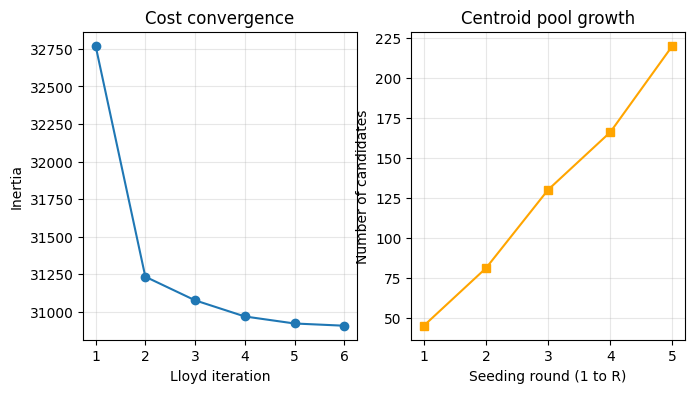

In [17]:
# Extract histories
cost_history = result['cost_history']        # list of inertia per Lloyd iteration
iter_times = result['iter_times']            # list of times per iteration
n_centroids_history = result['n_centroids_history']  # list of candidate count after each seeding round

# 1. Plot cost vs iteration
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(range(1, len(cost_history)+1), cost_history, marker='o')
plt.xlabel('Lloyd iteration')
plt.ylabel('Inertia')
plt.title('Cost convergence')
plt.grid(True, alpha=0.3)

# 2. Plot number of centroids candidates vs seeding round
plt.subplot(1, 3, 2)
plt.plot(range(1, len(n_centroids_history)+1), n_centroids_history, marker='s', color='orange')
plt.xlabel('Seeding round (1 to R)')
plt.ylabel('Number of candidates')
plt.title('Centroid pool growth')
plt.grid(True, alpha=0.3)


In [18]:
#print(result)

In [21]:
from sklearn.cluster import KMeans

# Import the needed builder (it's in benchmark.py)
from src.benchmark import _build_bag
from src.kmeans_parallel import kmeans_parallel

# --- 1. Prepare data ---
sample_size = 50000
k_test = 50
X_sample = np.vstack(X_bag_full.take(sample_size))  # (sample_size, n_features)

# Build the Dask Bag properly 
bag = _build_bag(client, X_sample, num_partitions=8)

# --- 2. Run your implementation (keep the clf object) ---
clf = kmeans_parallel(k=k_test, l=25, r=5)
clf.compute_starting_centroids(bag, seed=42, track_centroids=True, policy='fixed')
clf.fit(bag, max_iter=100, track_convergence=True)
your_cost = clf.inertia(bag)

# --- 3. sklearn reference ---
skl = KMeans(n_clusters=k_test, n_init=5, random_state=42).fit(X_sample)
sklearn_cost = skl.inertia_

print(f"Your cost: {your_cost:.2f}")
print(f"sklearn cost: {sklearn_cost:.2f}")
print(f"Ratio: {your_cost / sklearn_cost:.3f}")

Doing Lloyd's iteration 0...
...iteration completed in 0.05 s
Doing Lloyd's iteration 1...
...iteration completed in 0.05 s
Doing Lloyd's iteration 2...
...iteration completed in 0.07 s
Doing Lloyd's iteration 3...
...iteration completed in 0.07 s
Doing Lloyd's iteration 4...
...iteration completed in 0.06 s
Doing Lloyd's iteration 5...
...iteration completed in 0.07 s
Doing Lloyd's iteration 6...
...iteration completed in 0.07 s
Doing Lloyd's iteration 7...
...iteration completed in 0.06 s
Doing Lloyd's iteration 8...
...iteration completed in 0.06 s
Doing Lloyd's iteration 9...
...iteration completed in 0.06 s
Doing Lloyd's iteration 10...
...iteration completed in 0.07 s
Doing Lloyd's iteration 11...
...iteration completed in 0.08 s
Doing Lloyd's iteration 12...
...iteration completed in 0.06 s
Doing Lloyd's iteration 13...
...iteration completed in 0.06 s
Doing Lloyd's iteration 14...
...iteration completed in 0.06 s
Doing Lloyd's iteration 15...
...iteration completed in 0.06 s
St

In [22]:
print(f"sklearn iterations for its BEST run: {skl.n_iter_}") 

sklearn iterations for its BEST run: 20


In [30]:
# --- 4. Plots ---
# Extract histories (available because we set track_*)
#cost_history = clf.cost_history_      # list per Lloyd iteration
#n_centroids_history = clf.n_centroids_history_  # list per seeding round
#final_centroids = clf.final_centroids

In [34]:
# (c) 2D projection: data + final centroids
#pca = PCA(n_components=2)
#X_2d = pca.fit_transform(X_sample)
#centroids_2d = pca.transform(final_centroids)

# Subsample for visibility (plot 2000 random points)
#np.random.seed(42)
#idx = np.random.choice(len(X_2d), size=min(2000, len(X_2d)), replace=False)
#X_sub = X_2d[idx]

#plt.subplot()#(1, 3, 3)
#plt.scatter(X_sub[:, 0], X_sub[:, 1], s=2, alpha=0.5, label='Data points')
#plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', marker='X', s=100, label='Final centroids')
#plt.xlabel('PC1')
#plt.ylabel('PC2')
#plt.title('Data and centroids (PCA projection)')
#plt.legend()
#plt.grid(True, alpha=0.3)

#plt.tight_layout()
#plt.savefig('kmeans_debug_plots.png', dpi=150)
#plt.show()

### Number of centroids (table 5)

In [ ]:
# same code as that for l over k, BUT there it was run without track_centroids=True (now default):
# either skip this entirely or rerun some parts (some already done)
# ?

### Average number of LLoyd iterations (similar to table 6)

In [12]:
# similar to table 6: can simply report number of lloyd iterations of kmeans parallel vs random 

### Run with different numbers of workers

In [1]:
shutdown_cluster(cluster, client)


NameError: name 'shutdown_cluster' is not defined

In [18]:
# 2 and 3 workers, k 500 

In [10]:
# griglia combinazini

num_part = [16]
num_works = [8, 7, 6, 5, 4, 3, 2] # con 8 workers già fatto in partitions/
#num_part = [512, 1024, 2048]
combos = [(w, p, 1, 5) for w in num_works for p in num_part ]
K_VALUES = [500]
avg_iters = 9
MAX_ITER_FIT = 80
SEED=42

In [ ]:
frames = []
#shutdown_cluster(cluster, client)
j= 0
for combo in combos:
    #dask.config.set({"distributed.scheduler.work-stealing": True})
    n = combo[0]
    cluster, client = launch_cluster(n)
    mt=client.run(lambda: __import__('ctypes').CDLL("libc.so.6").malloc_trim(0))
    print(mt)

    combo = [combos[j],]
    j += 1
    
    X_bag_full, _ = load_dataset(n_partitions=8*n,
                   client=client,
                   dataset_url=DATASET_URL_FULL,
                   raw_gz_path=RAW_GZ_PATH_FULL,
                   parquet_path=PARQUET_PATH_FULL,
                   parquet_path_workers=PARQUET_PATH_FULL,
                   col_names=COL_NAMES,
                   force_download=False)  # rebuild bag on new client
    
    df_n = run_benchmark(client, X_bag=X_bag_full,
                         combinations=combo,
                         # function assigning appropriate values (in particular n partitions = 8 * n workers)
                         k_values=K_VALUES, label=f"{n}_workers_full_libero_k_500_bis", 
                         max_iter_fit=MAX_ITER_FIT, seed=SEED,
                         averaging_iterations=avg_iters)
    
    df_n["num_workers"] = n
    frames.append(df_n)
    shutdown_cluster(cluster, client)

df_all = pd.concat(frames, ignore_index=True)

In [ ]:
# can also try with one worker only, but in that case set chunk_k smaller (fastest way is to modify default in kmeans_parallel.py in def _pairwise_d2_argmin_chunked(M, C, chunk_k=100): ...)

### Figure 5.1

In [ ]:
# check Luca??

## Cluster shutdown

In [5]:
shutdown_cluster(cluster, client)

NameError: name 'cluster' is not defined

## Compress `results` folder

In [24]:
!tar -czf ../results.tar.gz -C .. results

In [ ]:
# can then download easily from inside Jupyter to one's local terminal